In [2]:
from pathlib import Path
from utils.workdirectory import WorkDirectory
from utils.results_manager import ResultsManager
from utils import functions

import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import pandas as pd
import numpy as np
import uproot

In [9]:
%config InlineBackend.figure_format = 'retina'

In [10]:
def rank_by_mu_for(df: pd.DataFrame, obs_type: str = None) -> pd.DataFrame:
    df = df[df['obs_type'] == obs_type]
    return df.sort_values('mu', ascending=True).reset_index(drop=True)

def get_branch_as_df(files: list[Path], tree_name: str, vars: list[str]) -> pd.DataFrame:
    dfs = []
    for file in files:
        with uproot.open(file) as f:
            tree = f[tree_name]
            df = tree.arrays(vars, library="pd")
            dfs.append(df)
    return pd.concat(dfs, ignore_index=True)

def correlation_from_events(events_df: pd.DataFrame, cols: list[str] = None) -> pd.DataFrame:
    """
    Pearson correlation matrix for raw observables.
    Pass `cols` to restrict to a subset; otherwise uses all numeric columns.
    """
    if cols is None:
        use = events_df.select_dtypes(include=[np.number]).columns.tolist()
    else:
        use = cols
    corr_df = events_df[use].corr_df(method='pearson')
    corr_df.index = [c for c in corr_df.index]
    corr_df.columns = [c for c in corr_df.columns]
    return corr_df

def rearrange_corr_df(corr_df: pd.DataFrame) -> pd.DataFrame:
    from bamboo_hh.variables import REG
    all_vars_1D = REG.get_var_names('1D')
    missing_vars = set(all_vars_1D) - set(corr_df.index)
    if missing_vars:
        print(f"Variables in all_vars_1D but not in correlation matrix: {missing_vars}")
    common_vars = [var for var in all_vars_1D if var in corr_df.index]
    corr_df_ordered = corr_df.reindex(index=common_vars, columns=common_vars)
    return corr_df_ordered

def plot_corr_heatmap(corr: pd.DataFrame, out: Path, annotate_thresh: float = 0.7):
    """
    Lower-triangular correlation heatmap with diverging colormap centered at 0.
    If annotate_thresh is set, annotate cells with |rho| >= threshold.
    """
    corr = corr.copy()
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    data = corr.mask(mask)

    fig, ax = plt.subplots(figsize=(16, 14))
    im = ax.imshow(data, cmap='viridis', 
                   norm=TwoSlopeNorm(vmin=-1, vcenter=0.0, vmax=1), 
                   origin='upper')  # Pass vmin/vmax to TwoSlopeNorm instead
    
    ax.set_xticks(range(len(corr.columns)))
    ax.set_yticks(range(len(corr.index)))
    ax.set_xticklabels(corr.columns, rotation=90, fontsize=12)
    ax.set_yticklabels(corr.index, fontsize=12)
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(r'Pearson $\rho$',fontsize=16)
    cbar.ax.tick_params(labelsize=12)

    if annotate_thresh is not None:
        th = float(annotate_thresh)
        for i in range(len(corr.index)):
            for j in range(len(corr.columns)):
                if j >= i:  # upper triangle masked
                    continue
                rho = corr.iat[i, j]
                if pd.notna(rho) and abs(rho) >= th:
                    ax.text(j, i, f"{rho:.2f}", ha='center', va='center', fontsize=8, color='black')

    # ax.set_title(title, fontsize=12)
    fig.tight_layout()
    fig.savefig(out, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)

def curation_by_correlation(df: pd.DataFrame,
                          corr: pd.DataFrame,
                          tau: float = 0.70,
                          max_vars: int = None) -> pd.DataFrame:
    """
    Walk the ranked 1D LLR list (best mu first). Keep a candidate if its *raw*
    observable has |rho| <= tau with *every* raw observable already kept.
    Returns a small table describing the selection.
    """
    kept = []
    decisions = []  # audit trail

    # make name access robust
    corr_index = [c for c in corr.index]
    corr.columns = [c for c in corr.columns]
    corr.index   = corr_index

    for _, row in df.iterrows():
        name_llr  = row['obs_name']
        base      = row['obs_name'].removesuffix('_llr')
        mu        = float(row['mu'])

        # If we don't have this base observable in the corr matrix, keep (be lenient)
        if base not in corr.index or base not in corr.columns:
            keep = False
            max_rho = np.nan
            culprit = None
        else:
            # compute max absolute corr to anything we've already kept
            if kept:
                rhos = [abs(corr.loc[base, k]) if (k in corr.columns) else np.nan for k in kept]
                max_rho = np.nanmax(rhos)
                # culprit = kept[np.nanargmax(rhos)] if not np.isnan(max_rho) else None
                culprit = kept[int(np.nanargmax(rhos))] if not np.isnan(max_rho) else None
                keep = (np.isnan(max_rho) or (max_rho <= tau))
            else:
                keep = True
                max_rho = np.nan
                culprit = None

        decisions.append({
            'obs_name_llr': name_llr,
            'raw_obs': base,
            'mu': mu,
            'keep': bool(keep),
            'max_abs_corr_to_kept': max_rho,
            'most_correlated_with': culprit
        })

        if keep:
            kept.append(base)
            if max_vars is not None and len(kept) >= max_vars:
                break

    sel = pd.DataFrame(decisions)
    curated = sel[sel['keep']].reset_index(drop=True).drop(columns=['keep'])
    return curated

In [11]:
projectdir = Path('/eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New')
workdir = 'LLR_odd'
file_path  = projectdir / workdir / 'fits_new' / 'summary_results.txt'
df = ResultsManager.load_summary_files(file_path)
df_llrs_from_1D = rank_by_mu_for(df, obs_type = 'llr_from_1D')
df_llrs_from_1D

,obs_name,mu,sigma1_min,sigma1_max,sigma2_min,sigma2_max,obs_type,n_variables
0,jj_l_dR_llr,421.5,302.9,587.8,228.0,785.7,llr_from_1D,1
1,jj_lnu_dR_llr,432.0,310.4,602.5,233.7,805.3,llr_from_1D,1
2,WW_mInv_llr,538.2,385.5,754.9,289.1,1013.0,llr_from_1D,1
3,jj_lnu_dPhi_llr,554.9,398.7,773.9,300.2,1034.0,llr_from_1D,1
4,bjets_pt_bb_llr,581.8,418.0,811.3,314.7,1084.0,llr_from_1D,1
...,...,...,...,...,...,...,...,...
63,ak4_jet0_eta_llr,4000.0,3988.0,8050.0,3234.0,12070.0,llr_from_1D,1
64,ak4_jet3_eta_llr,4000.0,3985.0,8050.0,3039.0,11360.0,llr_from_1D,1
65,nAK4_nonbtag_llr,4000.0,2943.0,5897.0,2195.0,8125.0,llr_from_1D,1
66,ak4_jet0_phi_llr,NaN,NaN,NaN,NaN,NaN,llr_from_1D,1


In [12]:
if False:
    # Run this to produce the correlation matrix
    wd = WorkDirectory(projectdir / 'JetTop_odd')
    all_files = functions.get_mc_files(wd.resultsdir)
    df_events = get_branch_as_df(all_files, 'SL_4j_resolved', var_names)
    print("\nComputing correlation matrix...")
    corr_df = correlation_from_events(df_events)
    corr_df.to_csv(Path('disc_study') / 'correlation_matrix_pearson.csv')
else:
    # Or this to load the correlation matrix csv
    corr_csv = Path('disc_study') / 'correlation_matrix_pearson.csv'
    corr_df = pd.read_csv(corr_csv, index_col=0)


Variables in all_vars_1D but not in correlation matrix: {'ak8_btag0_pt', 'lep1_phi', 'ak4_jet0_phi', 'll_pt', 'bfatjet_mass', 'll_dPhi', 'nAK8_btag', 'lep1_pt', 'bfatjet_msoftdrop', 'lep1_iso', 'ak8_btag0_phi', 'll_dR', 'll_dEta', 'ak8_btag0_eta', 'mll', 'lep1_eta'}


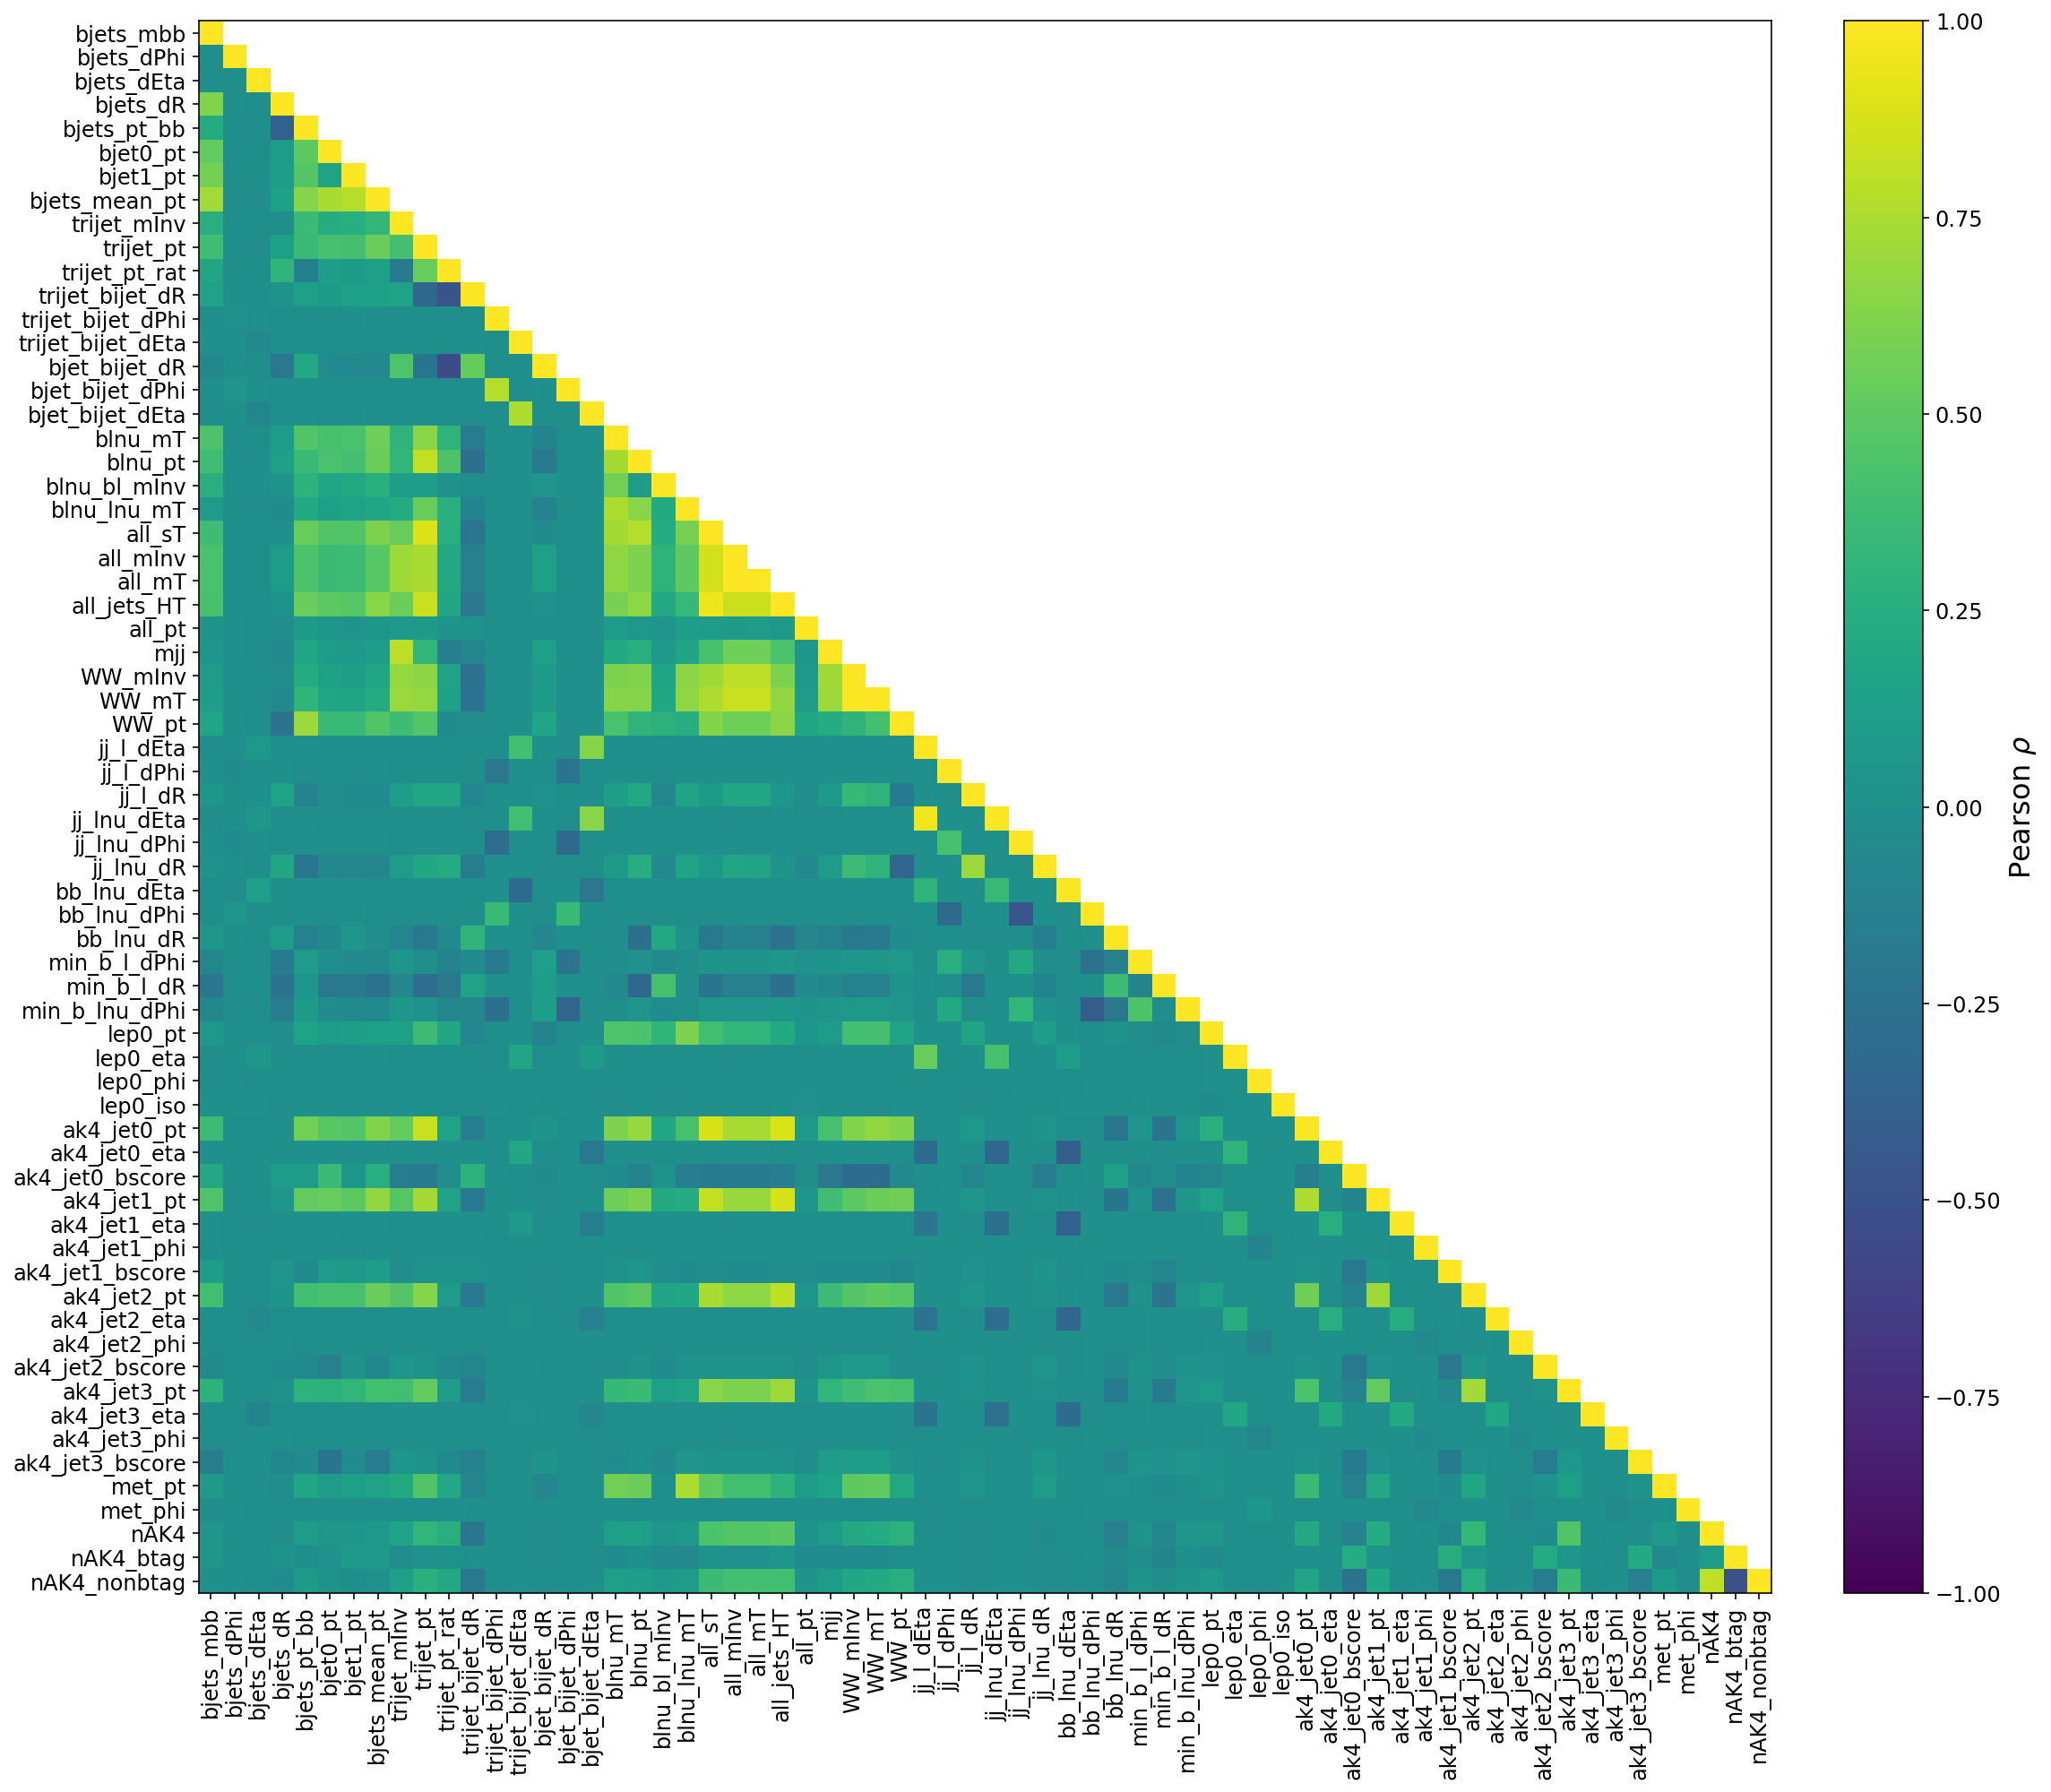

In [13]:
corr_df = rearrange_corr_df(corr_df)
plot_corr_heatmap(corr_df, Path('disc_study') / 'correlation_heatmap_pearson.pdf', annotate_thresh=1)

In [14]:
df_llrs_from_1D.head(25)

,obs_name,mu,sigma1_min,sigma1_max,sigma2_min,sigma2_max,obs_type,n_variables
0,jj_l_dR_llr,421.5,302.9,587.8,228.0,785.7,llr_from_1D,1
1,jj_lnu_dR_llr,432.0,310.4,602.5,233.7,805.3,llr_from_1D,1
2,WW_mInv_llr,538.2,385.5,754.9,289.1,1013.0,llr_from_1D,1
3,jj_lnu_dPhi_llr,554.9,398.7,773.9,300.2,1034.0,llr_from_1D,1
4,bjets_pt_bb_llr,581.8,418.0,811.3,314.7,1084.0,llr_from_1D,1
5,jj_l_dPhi_llr,589.2,424.4,821.8,318.8,1098.0,llr_from_1D,1
6,bjets_dR_llr,661.8,476.7,922.9,358.0,1234.0,llr_from_1D,1
7,min_b_l_dR_llr,742.8,533.7,1036.0,401.8,1385.0,llr_from_1D,1
8,trijet_bijet_dPhi_llr,779.8,560.3,1087.0,421.9,1464.0,llr_from_1D,1
9,trijet_pt_rat_llr,809.8,581.8,1129.0,438.1,1509.0,llr_from_1D,1


In [10]:
curated = curation_by_correlation(df_llrs_from_1D, corr_df, tau=0.7)
cur0p7 = curated.head(15)['raw_obs'].to_list()
curated.head(15)

,obs_name_llr,raw_obs,mu,max_abs_corr_to_kept,most_correlated_with
0,jj_l_dR_llr,jj_l_dR,421.5,NaN,None
1,jj_lnu_dR_llr,jj_lnu_dR,432.0,0.697834,jj_l_dR
2,WW_mInv_llr,WW_mInv,538.2,0.368604,jj_lnu_dR
3,jj_lnu_dPhi_llr,jj_lnu_dPhi,554.9,0.000303,jj_l_dR
4,bjets_pt_bb_llr,bjets_pt_bb,581.8,0.231409,WW_mInv
5,jj_l_dPhi_llr,jj_l_dPhi,589.2,0.414574,jj_lnu_dPhi
6,bjets_dR_llr,bjets_dR,661.8,0.376509,bjets_pt_bb
7,min_b_l_dR_llr,min_b_l_dR,742.8,0.240648,bjets_dR
8,trijet_bijet_dPhi_llr,trijet_bijet_dPhi,779.8,0.284861,jj_lnu_dPhi
9,trijet_pt_rat_llr,trijet_pt_rat,809.8,0.310757,bjets_dR


In [11]:
curated = curation_by_correlation(df_llrs_from_1D, corr_df, tau=0.75)
cur0p75 = curated.head(15)['raw_obs'].to_list()
curated.head(15)

,obs_name_llr,raw_obs,mu,max_abs_corr_to_kept,most_correlated_with
0,jj_l_dR_llr,jj_l_dR,421.5,NaN,None
1,jj_lnu_dR_llr,jj_lnu_dR,432.0,0.697834,jj_l_dR
2,WW_mInv_llr,WW_mInv,538.2,0.368604,jj_lnu_dR
3,jj_lnu_dPhi_llr,jj_lnu_dPhi,554.9,0.000303,jj_l_dR
4,bjets_pt_bb_llr,bjets_pt_bb,581.8,0.231409,WW_mInv
5,jj_l_dPhi_llr,jj_l_dPhi,589.2,0.414574,jj_lnu_dPhi
6,bjets_dR_llr,bjets_dR,661.8,0.376509,bjets_pt_bb
7,min_b_l_dR_llr,min_b_l_dR,742.8,0.240648,bjets_dR
8,trijet_bijet_dPhi_llr,trijet_bijet_dPhi,779.8,0.284861,jj_lnu_dPhi
9,trijet_pt_rat_llr,trijet_pt_rat,809.8,0.310757,bjets_dR


In [12]:
curated = curation_by_correlation(df_llrs_from_1D, corr_df, tau=0.8)
cur0p80 = curated.head(15)['raw_obs'].to_list()

In [13]:
set(cur0p7) - set(cur0p75)

{'bb_lnu_dPhi'}

In [14]:
set(cur0p75) - set(cur0p7)

{'WW_pt'}

In [15]:
print(len(cur0p75))
cur0p75

15


['jj_l_dR',
 'jj_lnu_dR',
 'WW_mInv',
 'jj_lnu_dPhi',
 'bjets_pt_bb',
 'jj_l_dPhi',
 'bjets_dR',
 'min_b_l_dR',
 'trijet_bijet_dPhi',
 'trijet_pt_rat',
 'blnu_bl_mInv',
 'WW_pt',
 'trijet_bijet_dR',
 'bjets_mbb',
 'bjets_dPhi']

In [16]:
from bamboo_hh.variables import vars_nd_creation
vars_nd_creation.create_from_combinations(cur0p75, outfile=Path('bamboo_hh/variables/vars_nd_curated_final.yaml'))

Generated YAML with 105 2D and 455 3D combinations
Saved to bamboo_hh/variables/vars_nd_curated_final.yaml
